In [0]:
# Since the repository is public, the storage account name and key has been removed from all the notebooks

storage_account_name = ""
storage_account_key = ""
spark.conf.set(
f"fs.azure.account.key.{storage_account_name}.dfs.core.windows.net",
storage_account_key
)

In [0]:
gold_path = f"abfss://curated@.dfs.core.windows.net/features_v1/"
gold_df = spark.read.parquet(gold_path)

# Convert to Pandas for visualization
pdf = gold_df.select("overall", "price", "review_year", "brand").toPandas()

pdf.head()


,overall,price,review_year,brand
0,4.0,18.81,2013,Neewer
1,2.0,18.81,2013,Neewer
2,4.0,18.81,2013,Neewer
3,3.0,18.81,2013,Neewer
4,5.0,11.43,2013,Shenit


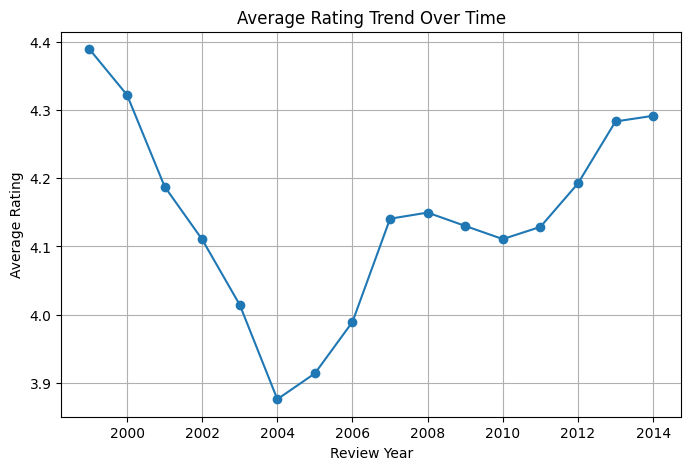

In [0]:
import matplotlib.pyplot as plt

ratings_over_time = pdf.groupby("review_year")["overall"].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(ratings_over_time["review_year"], ratings_over_time["overall"], marker='o')
plt.title("Average Rating Trend Over Time")
plt.xlabel("Review Year")
plt.ylabel("Average Rating")
plt.grid(True)
plt.show()


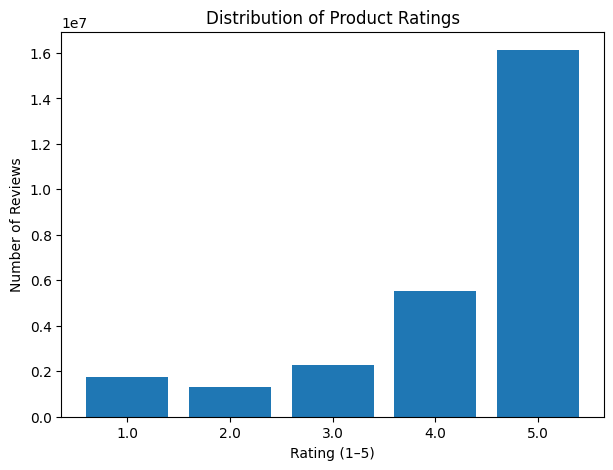

In [0]:
rating_dist = pdf["overall"].value_counts().sort_index()

plt.figure(figsize=(7,5))
plt.bar(rating_dist.index.astype(str), rating_dist.values)
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating (1–5)")
plt.ylabel("Number of Reviews")
plt.show()


**Analysis of the above charts:**

The first chart shows how the average product rating changes over time. We can see that ratings dropped in the early years, reaching their lowest point around the mid-2000s. After that, the ratings gradually increased and became more stable, staying above 4 in later years. This suggests that customer satisfaction improved as products and services became better over time.

The second chart shows the distribution of ratings from 1 to 5 stars. Most reviews are 5-star ratings, followed by 4-star ratings, while low ratings are much less common. This indicates that customers are generally satisfied with the products. Overall, both charts show that reviews are mostly positive and satisfaction has improved over time.